In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import time

In [ ]:
# Load data
df = pd.read_csv("Data/heart_cleveland_upload.csv")
df.head(10)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0
5,64,1,0,170,227,0,2,155,0,0.6,1,0,2,0
6,63,1,0,145,233,1,2,150,0,2.3,2,0,1,0
7,61,1,0,134,234,0,0,145,0,2.6,1,2,0,1
8,60,0,0,150,240,0,0,171,0,0.9,0,0,0,0
9,59,1,0,178,270,0,2,145,0,4.2,2,0,2,0


In [ ]:

X = df.drop("condition", axis=1)
y = df["condition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


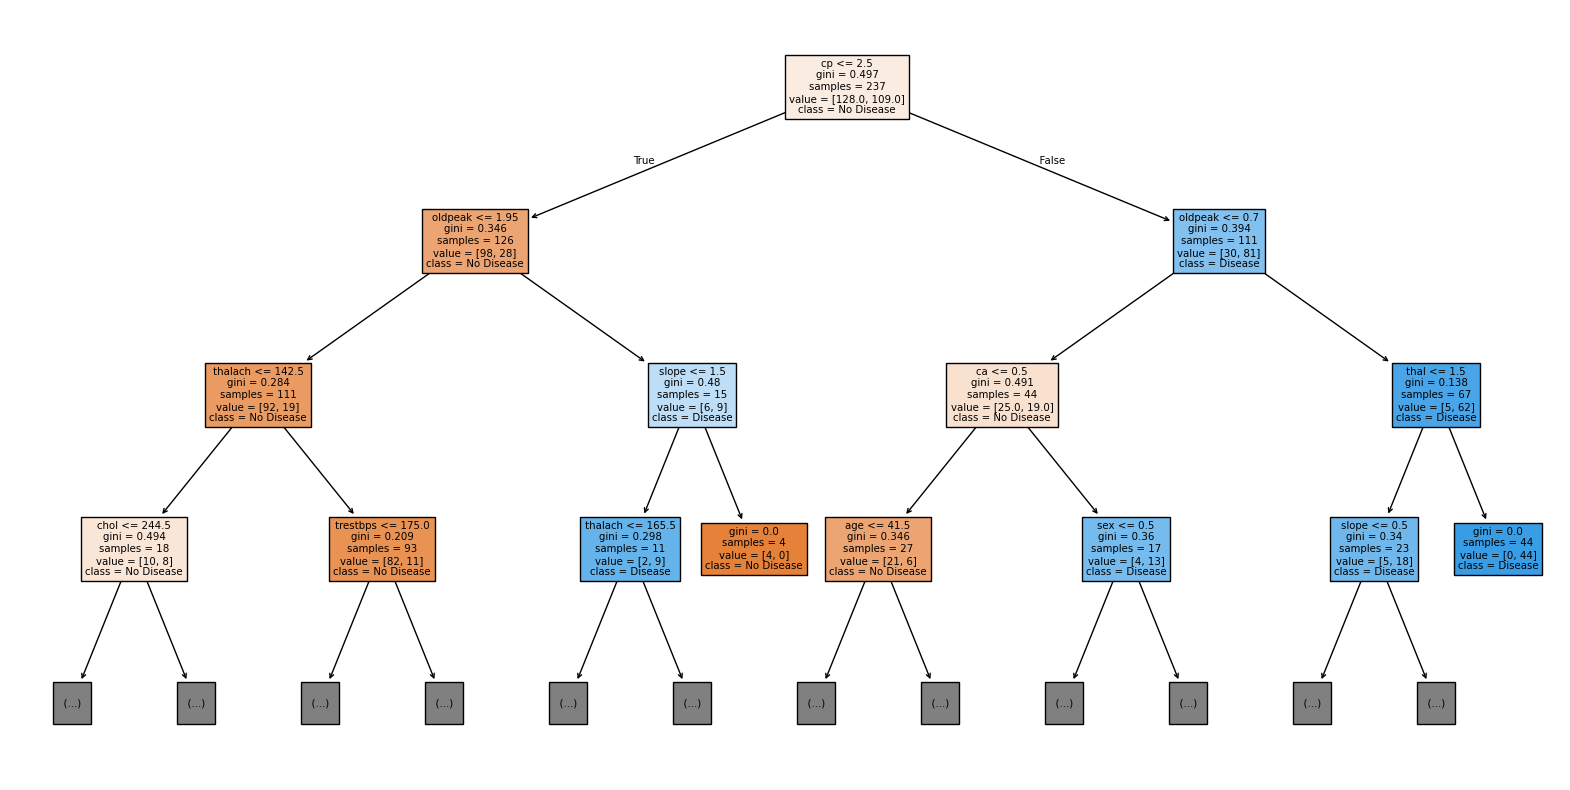

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    max_depth=3
)
plt.show()


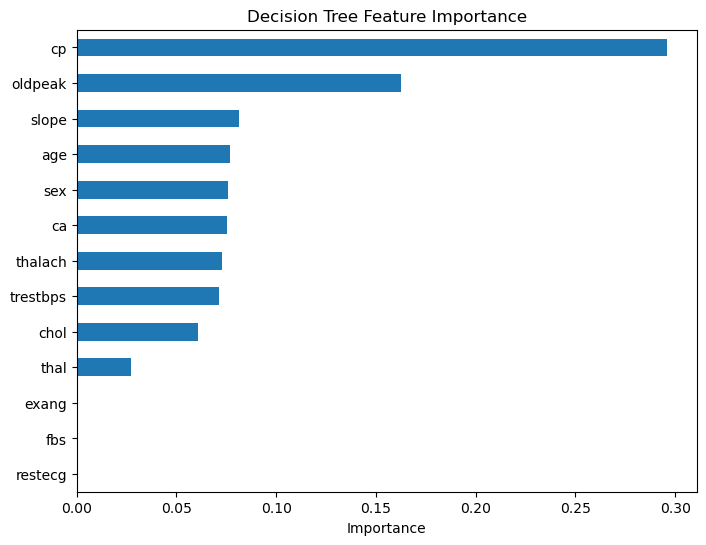

In [ ]:
importances = pd.Series(dt.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh")
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.show()

The most important feature in the Decision Tree model is cp (chest pain type), followed by oldpeak and slope. This suggests that chest pain characteristics and exercise-related heart measurements are the strongest indicators for predicting heart disease in the dataset.

These results are medically reasonable because abnormal chest pain and ECG-related measurements are commonly associated with cardiovascular problems. Features such as thalach (maximum heart rate) and ca (number of major vessels) also contribute to the prediction, while features like fbs and restecg have very little impact on the model.

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
    }

dt_metrics = evaluate(dt, X_test, y_test)
rf_metrics = evaluate(rf, X_test, y_test)

comparison = pd.DataFrame([dt_metrics, rf_metrics],
                          index=["Decision Tree", "Random Forest"])
comparison

,Accuracy,Precision,Recall,F1-score
Decision Tree,0.783333,0.800000,0.714286,0.754717
Random Forest,0.883333,0.956522,0.785714,0.862745


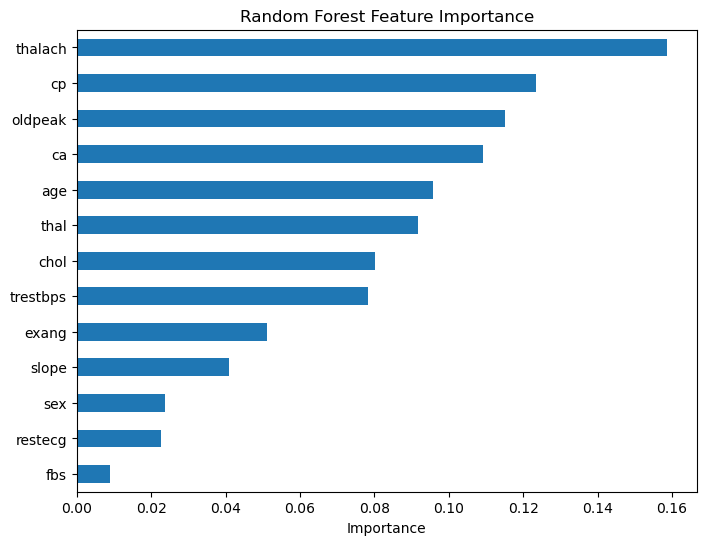

In [ ]:
rf_importances = pd.Series(rf.feature_importances_, index=X.columns)
rf_importances = rf_importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
rf_importances.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

Random Forest shows a slightly different feature importance ranking compared to Decision Tree. The most important feature is thalach (maximum heart rate achieved), followed by cp (chest pain type), oldpeak, and ca. Unlike the Decision Tree, Random Forest distributes importance more evenly across multiple features instead of relying heavily on a single variable.

In terms of performance, Random Forest outperformed Decision Tree with an accuracy of 88.33% and an F1-score of 0.8627, compared to 78.33% and 0.7547 for Decision Tree. This improvement happens because Random Forest combines predictions from many trees, reducing overfitting and improving generalization on unseen data.

In [ ]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [ ]:
print("Best Parameters:", grid.best_params_)
print("Best CV F1-score:", grid.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Best CV F1-score: 0.7916955441091931


In [ ]:
best_rf = grid.best_estimator_
best_rf_metrics = evaluate(best_rf, X_test, y_test)

pd.DataFrame([rf_metrics, best_rf_metrics],
             index=["Random Forest Default", "Random Forest Tuned"])

,Accuracy,Precision,Recall,F1-score
Random Forest Default,0.883333,0.956522,0.785714,0.862745
Random Forest Tuned,0.883333,0.920000,0.821429,0.867925


In [ ]:
start = time.time()
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
gb_time = time.time() - start

start = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - start

gb_metrics = evaluate(gb, X_test, y_test)

In [ ]:
pd.DataFrame(
    [dt_metrics, rf_metrics, gb_metrics],
    index=["Decision Tree", "Random Forest", "Gradient Boosting"]
)


,Accuracy,Precision,Recall,F1-score
Decision Tree,0.783333,0.800000,0.714286,0.754717
Random Forest,0.883333,0.956522,0.785714,0.862745
Gradient Boosting,0.866667,0.916667,0.785714,0.846154


In [ ]:
print(f"Random Forest training time: {rf_time:.3f} sec")
print(f"Gradient Boosting training time: {gb_time:.3f} sec")

Random Forest training time: 0.123 sec
Gradient Boosting training time: 0.102 sec


Random Forest achieved the best overall performance with an accuracy of 88.33% and an F1-score of 0.8627. Its very high precision (95.65%) indicates that most positive predictions were correct, making it reliable for heart disease prediction.

Decision Tree showed the lowest performance, likely because a single tree is more prone to overfitting and weaker generalization on unseen data.

Gradient Boosting also performed well with an accuracy of 86.67% and an F1-score of 0.8462, but it was still slightly below Random Forest. Overall, Random Forest is the best choice due to its strong accuracy, stability, and balanced performance.